<a href="https://colab.research.google.com/github/vikramvundyala/python_AI-ML/blob/main/U2_MH2_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Perform customer segmentation using bank data into distinct categories based on their behavioral patterns

## Learning Objectives

At the end of the experiment, you will be able to:

* Understand clustering
* Find groups or clusters using K-means algorithm
* Visualize the high-dimensional data to low-dimensional data (2D) by applying t-SNE algorithm

In [ ]:
#@title  Mini Hackathon Walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Customer_Segmentation.mp4" type="video/mp4">
</video>
""")

## Domain Information

- **Customer segmentation** refers to the process of dividing a set of potential customers into groups (or segments) based on shared attributes, interests, and behaviors.
- One of the key pain points for bank marketing team is to know their customers and identify their needs.
- For this mini-hackathon, we will use the popular **K-Means clustering** algorithm to segment customers based on their behavior from the bank data. The basic concept is that consumers who share common traits would respond to marketing communication in a similar way so that the bank marketing team can reach out to each group in a relevant and effective way.

## Dataset

### Description

The dataset chosen for this mini hackathon is the behavior of customers in the bank for 6 months, this dataset is made up of 13 features.

**Attribute Information**

- **CUSTID:** Identification of Credit Cardholder
- **BALANCE:** Balance amount left in customer's account to make purchases
- **PURCHASES:** Amount of purchases made from the account
- **INSTALLMENTS_PURCHASES:** Amount of purchase done in installment
- **CASH_ADVANCE:** Cash in advance given by the user
- **PURCHASES_FREQUENCY:** How frequently the Purchases are being made score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- **CASH_ADVANCE_FREQUENCY:** How frequently the cash in advance being paid
- **CASH_ADVANCE_TRX:** Number of Transactions made with "Cash in Advance"
- **CREDIT_LIMIT:** Limit of Credit Card for user
- **PAYMENTS:** Amount of Payment done by a user
- **MINIMUM_PAYMENTS:** Minimum amount of payments made by a user
- **PRC_FULL_PAYMENT:** Percent of full payment paid by a user
- **TENURE:** Tenure of credit card service for user

**Note:** The currency values mentioned above are in "dollars"

## Grading = 10 Marks

## Setup Steps

In [1]:
#@title Run this cell to complete the setup for this Notebook

from IPython import get_ipython
ipython = get_ipython()

notebook="U2_MH2_Customer_Segmentation" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Marketing_data_clustering.csv")
    print ("Setup completed successfully")
    return

setup()

Setup completed successfully


### Importing Required Packages

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

## **Stage 1:** Data Pre-Processing (2 Marks)

- Replace the missing values in any other column appropriately with mean / median / mode.

  Hint: Use pandas [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) function to replace the missing values

- Perform correlation on the data features and remove highly correlated features from the data
  
  Hint: Use pandas [corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

- Drop any unwanted columns
  
  Hint: Use pandas [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

- Perform `StandardScaler()` on the data features
  
  Hint: Use Sklearns [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)



In [3]:
# YOUR CODE HERE
df = pd.read_csv("Marketing_data_clustering.csv")
df.head()

,CUST_ID,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,95.40,95.4,0.00000,0.166667,0.000000,0,1000.0,201.802084,139.509787,0.0,12
1,C10005,817.714335,16.00,0.0,0.00000,0.083333,0.000000,0,1200.0,678.334763,244.791237,0.0,12
2,C10008,1823.652743,436.20,436.2,0.00000,1.000000,0.000000,0,2300.0,679.065082,532.033990,0.0,12
3,C10009,1014.926473,861.49,200.0,0.00000,0.333333,0.000000,0,7000.0,688.278568,311.963409,0.0,12
4,C10015,2772.772734,0.00,0.0,346.81139,0.000000,0.083333,1,3000.0,805.647974,989.962866,0.0,12


In [4]:
df.describe()
df.nunique()
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0
CASH_ADVANCE_TRX,0
CREDIT_LIMIT,0
PAYMENTS,0


In [5]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].mean())
df.isna().sum()

,0
CUST_ID,0
BALANCE,0
PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0
CASH_ADVANCE_TRX,0
CREDIT_LIMIT,0
PAYMENTS,0


In [6]:
df.drop(['CUST_ID'], axis=1, inplace=True)
df.head()


df.drop(['TENURE'], axis=1, inplace=True)
df.head()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,40.900749,95.40,95.4,0.00000,0.166667,0.000000,0,1000.0,201.802084,139.509787,0.0
1,817.714335,16.00,0.0,0.00000,0.083333,0.000000,0,1200.0,678.334763,244.791237,0.0
2,1823.652743,436.20,436.2,0.00000,1.000000,0.000000,0,2300.0,679.065082,532.033990,0.0
3,1014.926473,861.49,200.0,0.00000,0.333333,0.000000,0,7000.0,688.278568,311.963409,0.0
4,2772.772734,0.00,0.0,346.81139,0.000000,0.083333,1,3000.0,805.647974,989.962866,0.0


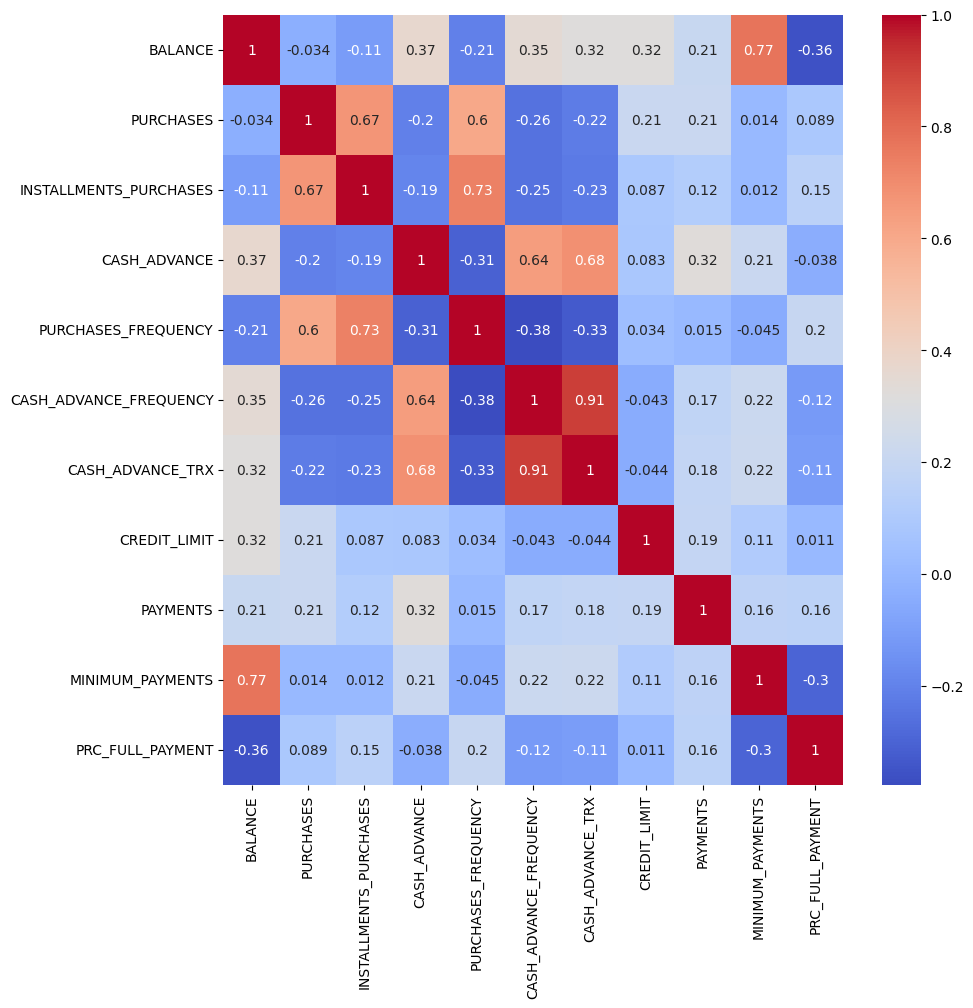

In [7]:
corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [8]:
df.drop(['CASH_ADVANCE_FREQUENCY'], axis=1, inplace=True)
df.head()

df.drop(['PRC_FULL_PAYMENT'], axis=1, inplace=True)
df.head()

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,40.900749,95.40,95.4,0.00000,0.166667,0,1000.0,201.802084,139.509787
1,817.714335,16.00,0.0,0.00000,0.083333,0,1200.0,678.334763,244.791237
2,1823.652743,436.20,436.2,0.00000,1.000000,0,2300.0,679.065082,532.033990
3,1014.926473,861.49,200.0,0.00000,0.333333,0,7000.0,688.278568,311.963409
4,2772.772734,0.00,0.0,346.81139,0.000000,1,3000.0,805.647974,989.962866


In [9]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[-1.13359969, -0.63261322, -0.31715131, ..., -0.90479325,
        -0.88170901, -0.94317715],
       [-0.37630323, -0.8116596 , -0.6893926 , ..., -0.82224017,
        -0.19700475, -0.64209751],
       [ 0.60436139,  0.13588811,  1.01261629, ..., -0.36819827,
        -0.19595539,  0.1793477 ],
       ...,
       [-1.15745725,  0.14783957,  0.5467294 , ..., -0.90479325,
        -0.47832047, -1.08096394],
       [-1.1077884 , -0.18251679,  0.46166798, ..., -0.90479325,
        -0.81864971, -0.86420132],
       [-0.87406153,  1.20272491,  1.26155753, ..., -0.90479325,
         0.18367824, -0.82950517]])

## **Stage 2:** K Means (3 Marks)

- Find the right number of clusters to be chosen using the elbow method
  
- Perform K-Means on the chosen optimal number of clusters

  **Hint:** Refer to this [link](https://towardsdatascience.com/clustering-algorithms-for-customer-segmentation-af637c6830ac) for finding the k-clusters using elbow method and applying kmeans

range(1, 11)
[26946.00000000003, 20983.100277515583, 17402.44403216943, 15797.564397004357, 14185.513929986611, 13194.288032592336, 12381.131060545822, 11967.944942580734, 11125.251392918224, 10538.397769356672]


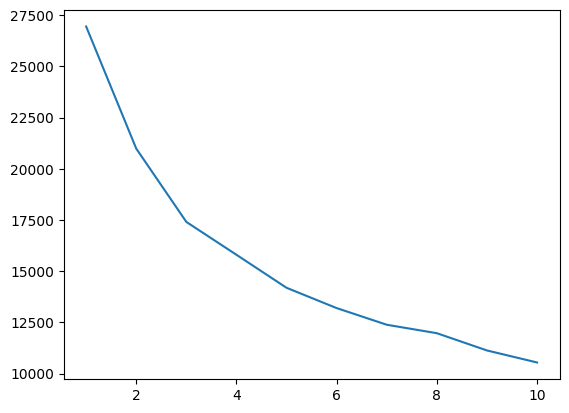

In [10]:
# YOUR CODE HERE
sse = []
kRange = range(1, 11)

for k in kRange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    sse.append(kmeans.inertia_)

print(kRange)
print(sse)

plt.plot(kRange, sse)
plt.show()


In [ ]:
type(df_scaled)

numpy.ndarray

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, make_scorer

# Create a silhouette score scorer
silhouette_scorer = make_scorer(silhouette_score)

# Define parameter grid
param_grid = {
    'n_clusters': [2, 3, 4, 5, 6, 7, 8 ,9 , 10, 11],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20, 30],
    'max_iter': [100, 200, 300]
}

# Create KMeans instance
kmeans = KMeans(random_state=42)

# Create GridSearchCV instance
grid_search = GridSearchCV(
    estimator=kmeans,
    param_grid=param_grid,
    scoring=silhouette_scorer,
    cv=5,  # Using CV for stability, though not traditional for clustering
    n_jobs=-1
)

# Fit to data
grid_search.fit(df_scaled)

# Best parameters
print("Best parameters:", grid_search.best_params_)


Best parameters: {'init': 'k-means++', 'max_iter': 100, 'n_clusters': 2, 'n_init': 10}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


In [16]:

df.dtypes
df.isna().sum()

,0
BALANCE,0
PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
CASH_ADVANCE_TRX,0
CREDIT_LIMIT,0
PAYMENTS,0
MINIMUM_PAYMENTS,0


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  # ← handles NaNs
    ('scale',  StandardScaler()),
    ('pca',    PCA()),
    ('kmeans', KMeans(random_state=42))
])

# 2️⃣ Hyper‑parameter grid
param_grid = {
    'pca__n_components':  [2, 3, 4],
    'kmeans__n_clusters': [2, 3, 4, 5, 6],
    'kmeans__init':       ['k-means++', 'random']
}

# 3️⃣ Custom silhouette scorer (robust across sklearn versions)
def silhouette_scorer(estimator, X):
    # labels of the already‑fitted kmeans step
    labels = estimator.named_steps['kmeans'].labels_

    # short‑circuit if KMeans collapsed to <2 clusters
    if np.unique(labels).size < 2:
        return -1                         # silhouette undefined → worst score

    # transformed feature space (impute → scale → PCA)
    Z = estimator.named_steps['pca'].transform(
            estimator.named_steps['scale'].transform(
                estimator.named_steps['impute'].transform(X)))

    return silhouette_score(Z, labels)

# 4️⃣ “No‑split” CV (train = test = all rows)
idx = np.arange(len(df))
cv  = [(idx, idx)]

search = GridSearchCV(pipe,
                      param_grid,
                      scoring=silhouette_scorer,
                      cv=cv,
                      n_jobs=-1)

search.fit(df)          # df is your DataFrame
print("Best params:", search.best_params_)
print("Best silhouette:", round(search.best_score_, 3))

Best params: {'kmeans__init': 'k-means++', 'kmeans__n_clusters': 3, 'pca__n_components': 2}
Best silhouette: 0.394


## **Stage 3:** Apply **TSNE** with 2 components (n_components = 2) and visualize the clusters (3 Marks)

Hint: Use Sklearns [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

**Note:** Produce a visualization with distinctly isolated clusters and It is not necessary to plot the centroids



2994


ValueError: perplexity must be less than n_samples

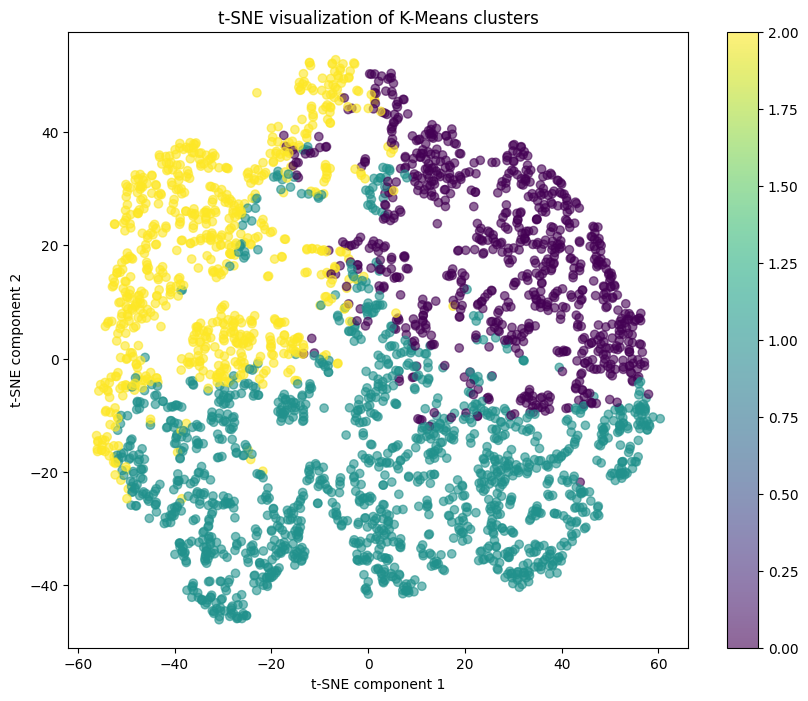

In [19]:
# Perform K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

print(clusters.size)

# Apply t-SNE for 2D visualization
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
X_tsne = tsne.fit_transform(df_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('t-SNE visualization of K-Means clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')

# Add cluster centers in t-SNE space (optional)
centers_tsne = tsne.fit_transform(kmeans.cluster_centers_)
plt.scatter(centers_tsne[:, 0], centers_tsne[:, 1], c='red', marker='X', s=200, alpha=0.8)
plt.show()

## **Stage 4:** Insights for each cluster

#### **Stage 4(a)** (1 Mark):
- To understand the behavior of the customers from each cluster print the respective centroid point values obtained from the scaled dataframe
- Get the original representation of the scaled centroid points using [inverse_transformation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.inverse_transform) technique

In [ ]:
# YOUR CODE HERE
scaled_centroids  = kmeans.cluster_centers_
print(scaled_centroids)

centroids_original  = scaler.inverse_transform(scaled_centroids)
print(centroids_original)

[[-0.39341099  0.70653247  0.73236796 -0.4688514   0.90099123 -0.50960602
   0.07885388 -0.03592598 -0.23188601]
 [ 0.30812117 -0.55335926 -0.57359373  0.36720643 -0.7056602   0.39912562
  -0.0617587   0.02813738  0.18161412]]
[[8.00165673e+02 6.89258243e+02 3.64376449e+02 1.12420759e+02
  7.27566548e-01 5.42205323e-01 3.38306602e+03 7.90440531e+02
  3.88233891e+02]
 [1.51977779e+03 1.30546004e+02 2.96775581e+01 6.55763528e+02
  1.29193924e-01 2.74449077e+00 3.04240619e+03 8.35026615e+02
  5.32826513e+02]]


#### **Stage 4(b)** (1 Mark):
- Report your observations in the form of text, about the customers based on the centroid points

Hint: If require use [clustermap](https://seaborn.pydata.org/generated/seaborn.clustermap.html)

In [ ]:
# YOUR ANALYSIS HERE

centroid_df = pd.DataFrame(centroids_original, columns=df.columns)
centroid_df

,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,800.165673,689.258243,364.376449,112.420759,0.727567,0.542205,3383.066021,790.440531,388.233891
1,1519.777794,130.546004,29.677558,655.763528,0.129194,2.744491,3042.406194,835.026615,532.826513
